# Surround-grating analysis

This notebook analyzes `spotWithAnnularGrating` with the grating restricted to the
**surround**. It follows the same workflow as the cone center/annulus notebooks:
database refresh, condition discovery, one-cell analysis, persistent saving,
population analysis, and an example-stimulus visualization.

The light level is reconstructed per epoch block. Fixed `EL...` filters come from
the raw Stage device configurator; embedded `FW...` text there is ignored. The
numeric FilterWheel reading comes independently from protected metadata and must
agree across every epoch in a block. The resulting maximum is the calibrated R*/s
at normalized display intensity 1; the actual background is
`max_light_level × backgroundIntensity`.


In [1]:
import sys
import time

if sys.version_info[:2] != (3, 11):
    raise RuntimeError(
        f'This notebook requires the retinanalysis Python 3.11 kernel; '
        f'got Python {sys.version.split()[0]} at {sys.executable}')

import_started = time.perf_counter()
import numpy as np
import pandas as pd
from IPython.display import display

import retinanalysis as ra
from retinanalysis.SCutils import explore as sc
from retinanalysis.SCutils.protocols import spot_annular_grating as sag

SITE = 'surround'
SITE_LABEL = 'Surround-grating analysis'
MAX_SERIES_RESISTANCE = 30e6
STORE_PATH = sag.store_dir() / f'{SITE}_grating'

print(f'Python {sys.version.split()[0]} | {sys.executable}')
print(f'Imports ready in {time.perf_counter() - import_started:.2f} s')
print(f'Saved records: {STORE_PATH}')

Python 3.11.13 | /Users/chrischen/opt/anaconda3/envs/retinanalysis/bin/python
Imports ready in 0.64 s
Saved records: /Volumes/ChrisNewSSD/retinanalysis_output/spot_annular_grating/surround_grating


## 1. Load or refresh the single-cell database

Set `UPDATE_DATABASE = True` when new Symphony H5/JSON metadata should be ingested.
The default connects to the existing local DataJoint database without changing it.


In [2]:
UPDATE_DATABASE = False
ra.djconnect()

if UPDATE_DATABASE:
    database_report = ra.populate_database()
    print(f"newly added: {len(database_report['added'])}")
    print(f"refreshed: {len(database_report['updated'])}")
    print(f"errored: {len(database_report['skipped'])}")
    print(f"database: {len(database_report['experiments'])} experiments; "
          f"{len(database_report['stale'])} still out of date")
else:
    print('Connected to the existing database. Set UPDATE_DATABASE=True to ingest changes.')


Connected to the existing database. Set UPDATE_DATABASE=True to ingest changes.


## 2. Search the database for surround-grating recordings

Discovery keeps every recorded cell type, numeric FilterWheel setting, bright-bar
contrast, and bar width. Series resistance still resolves and validates
`onlineAnalysis`. Each row is one explicit cell × mode × NDF combination ×
background × bright contrast × bar-width condition, although the compact table
omits the bright-contrast and database bookkeeping columns requested for this view.

`ndf_combination` and `max_light_level` come from the block-level light reader; no
protocol `maxIntensity` parameter is assumed. `date_index` uses the complete sorted
protocol date list, so the same value works in Section 3 even when a date has no
recording for this grating site.

**Manual EL3 repair.** On the sessions listed in `MANUAL_EL3_SESSIONS`, Stage never
wrote the fixed filter into its device configuration, so the light reader resolves
those blocks against rig E's *no-filter* entry and reports a maximum of 30000000
R*/s — a thousand times every other block on that rig, and not a level any of these
retinas were exposed to. The filter was EL3, physically mounted but unrecorded, and
the cell below substitutes it and recomputes the light level, giving 30000 R*/s.
Repaired conditions are marked in the `light_fix` column.

This is patched here rather than in the shared light reader on purpose: it is a
hand-checked claim about specific sessions, not a rule the reader should apply on
its own. It follows that the repair reaches only the blocks this notebook loads —
four of the seven listed sessions have surround blocks, giving 13 blocks and 6
conditions; the rest of each session, and the same problem in the other grating
notebooks, is left alone.

What backs the claim: EL3 is the only fixed filter rig E has ever recorded, and
five of these seven sessions logged it on some blocks and not others — counting
every protocol, 2026-03-03_E recorded it on 66 blocks and dropped it on 48. That
intermittency inside one session is what rules out the filter having actually been
removed. 2025-10-15_E and 2026-01-02_E_2 never logged it on any block of any
protocol, so they rest on the rig-wide argument alone. After the repair the
affected blocks sit at 9000 and 15000 R*, on the same rungs as every other rig-E
recording.

In [2]:
protocol_index = sc.find_blocks(sag.PROTOCOL, show=False)
protocol_dates = sorted(protocol_index.exp_name.dropna().unique())
date_index_map = {exp_name: index + 1 for index, exp_name in enumerate(protocol_dates)}

df_blocks = sag.find_blocks(show=False)
df_blocks = sag.check_series_resistance(
    df_blocks, max_series_resistance=MAX_SERIES_RESISTANCE)
site_blocks = df_blocks[df_blocks.grating_site.eq(SITE)].copy()

# Manual light-metadata repair, local to this notebook. See the markdown above
# for the evidence; only blocks that recorded no fixed filter at all are touched,
# so anything Stage did record keeps what it recorded.
MANUAL_EL3_SESSIONS = ('2025-10-15_E', '2025-12-16_E', '2026-01-02_E_2',
                       '2026-01-27_E', '2026-03-03_E', '2026-03-03_E_2',
                       '2026-04-03_E_2')
MANUAL_EL3_FILTERS = ('EL3',)

needs_el3 = (site_blocks.exp_name.isin(MANUAL_EL3_SESSIONS)
             & site_blocks.fixed_ndfs.apply(len).eq(0))
repaired_block_ids = set(site_blocks.loc[needs_el3, 'block_id'].astype(int))
for row in site_blocks.index[needs_el3]:
    wheel = site_blocks.at[row, 'filter_wheel_ndf']
    maximum = ra.visual_stimulus_max('E', MANUAL_EL3_FILTERS, wheel)
    rstar = maximum * site_blocks.at[row, 'backgroundIntensity']
    site_blocks.at[row, 'fixed_ndfs'] = MANUAL_EL3_FILTERS
    site_blocks.at[row, 'fixed_ndf_source'] = 'manual (notebook)'
    site_blocks.at[row, 'ndf_combination'] = ' + '.join(
        [*MANUAL_EL3_FILTERS, f'FW{wheel:g}'])
    site_blocks.at[row, 'max_light_level'] = maximum
    site_blocks.at[row, 'max_rstar'] = maximum
    site_blocks.at[row, 'rstar'] = rstar
    site_blocks.at[row, 'rstar_level'] = sag.round_rstar(rstar)
    site_blocks.at[row, 'light_level'] = f'{sag.round_rstar(rstar):g}R*'
    site_blocks.at[row, 'rstar_measured'] = True
print(f'manual EL3 repair: {len(repaired_block_ids)} {SITE} block(s) across '
      f"{site_blocks.loc[needs_el3, 'exp_name'].nunique()} session(s)")

selected = sag.group_blocks(
    site_blocks, show=False,
    require_filter_wheel=False,
    allowed_bright_contrast=None,
    min_bar_width=None,
    min_epochs=None,
    separate_bright_contrast=True,
    collapse_bar_widths=False)
selected = selected.sort_values(
    ['exp_name', 'cell_label', 'onlineAnalysis', 'ndf_combination',
     'backgroundIntensity', 'bright', 'bar_width']).reset_index(drop=True)
selected.insert(0, 'date_index', selected.exp_name.map(date_index_map).astype(int))
# group_blocks keeps the pooled block ids, so the repair flag survives grouping.
selected['light_fix'] = [
    'EL3 added manually'
    if repaired_block_ids.intersection(
        int(value) for value in str(ids).split(',') if value.strip()) else ''
    for ids in selected.block_ids]

print(f'{SITE_LABEL}: {len(selected)} conditions across '
      f'{selected.exp_name.nunique()} experiments and '
      f"{selected.groupby(['exp_name', 'cell_label']).ngroups} cells")
condition_columns = [
    'date_index', 'exp_name', 'cell_label', 'cell_type_short', 'onlineAnalysis',
    'ndf_combination', 'light_fix', 'filter_wheel_ndf', 'max_light_level',
    'backgroundIntensity', 'spot_intensity', 'bar_width', 'aperture',
    'annulus_inner', 'annulus_outer',
]
condition_columns = [column for column in condition_columns if column in selected]
sc.scroll_table(
    selected[condition_columns], height=430,
    num_cols=('date_index', 'filter_wheel_ndf', 'max_light_level',
              'backgroundIntensity', 'spot_intensity', 'bar_width', 'aperture',
              'annulus_inner', 'annulus_outer'))

  2026-01-02_E_2: cannot open the h5 (FileNotFoundError) — 2 block(s) have no series-resistance reading
reading the trace for 23 block(s) whose mode the label does not settle (0 never labelled, 23 contradicted)
series resistance read for 231/233 blocks

onlineAnalysis vs the amplifier (as recorded, before any relabelling)
series resistance says  (no reading)  cell-attached  whole-cell
onlineAnalysis says                                            
cell-attached                      0            178           2
whole-cell                         2             31          20

33 block(s) where the amplifier disagrees:
      exp_name cell_label cell_type_short      recorded   analyzed as  Rs (MOhm)  n_epochs  block_id                                                                                                                                  rs_flag
  2025-10-15_E      Cell6      ON-parasol           exc extracellular       0.00        33     18847                                      

/Users/chrischen/Documents/GitHub/retinanalysis/src/retinanalysis/SCutils/protocols/spot_annular_grating.py:1010: RuntimeWarning: All-NaN slice encountered
  agg['rs_mohm'] = ('series_resistance', lambda s: np.round(np.nanmedian(s) / 1e6, 2))


date_index,exp_name,cell_label,cell_type_short,onlineAnalysis,ndf_combination,light_fix,filter_wheel_ndf,max_light_level,backgroundIntensity,spot_intensity,bar_width,aperture,annulus_inner,annulus_outer
1,2025-10-15_E,Cell6,ON-parasol,extracellular,EL3 + FW0,EL3 added manually,0.0,30000.0,0.3,0.3,100.0,250.0,350.0,1200.0
1,2025-10-15_E,Cell7,ON-parasol,extracellular,EL3 + FW0,EL3 added manually,0.0,30000.0,0.3,0.3,100.0,350.0,450.0,1200.0
1,2025-10-15_E,Cell8,ON-parasol,extracellular,EL3 + FW0,EL3 added manually,0.0,30000.0,0.3,0.3,100.0,350.0,450.0,1200.0
2,2025-10-22_E,Cell1,ON-parasol,extracellular,EL3 + FW0,,0.0,30000.0,0.3,0.3,100.0,300.0,400.0,1200.0
2,2025-10-22_E,Cell2,bipolar,extracellular,EL3 + FW0,,0.0,30000.0,0.3,0.3,100.0,0.0,150.0,1200.0
2,2025-10-22_E,Cell3,OFF-parasol,extracellular,EL3 + FW0,,0.0,30000.0,0.3,0.15,100.0,350.0,450.0,1200.0
2,2025-10-22_E,Cell4,ON-parasol,extracellular,EL3 + FW0,,0.0,30000.0,0.3,0.3,100.0,350.0,450.0,1200.0
3,2025-11-06_E,Cell1,ON-parasol,extracellular,EL3 + FW0,,0.0,30000.0,0.3,0.3,100.0,0.0,450.0,1200.0
3,2025-11-06_E,Cell2,ON-parasol,extracellular,EL3 + FW0,,0.0,30000.0,0.3,0.3,100.0,0.0,450.0,1200.0
3,2025-11-06_E,Cell3,ON-parasol,extracellular,EL3 + FW0,,0.0,30000.0,0.3,0.3,100.0,0.0,400.0,1200.0


'\n<style>\n.ra-tbl { overflow: auto; }\n.ra-tbl table { border-collapse: collapse; font-size: 12.5px;\n                font-variant-numeric: tabular-nums; }\n.ra-tbl th { position: sticky; top: 0; z-index: 1; text-align: left;\n             font-weight: 600; padding: 4px 12px 4px 0;\n             border-bottom: 1px solid rgba(128,128,128,0.6);\n             background: var(--jp-layout-color0, #fff); }\n.ra-tbl td { padding: 2px 12px 2px 0; vertical-align: top;\n             white-space: nowrap; }\n.ra-tbl tr.grp > td { border-top: 1px solid rgba(128,128,128,0.28); }\n.ra-tbl td.num { text-align: right; }\n.ra-tbl td.lead { font-weight: 600; }\n.ra-tbl summary { cursor: pointer; margin: 2px 0; }\n</style>\n<div class="ra-tbl" style="max-height:430px"><table><thead><tr><th>date_index</th><th>exp_name</th><th>cell_label</th><th>cell_type_short</th><th>onlineAnalysis</th><th>ndf_combination</th><th>light_fix</th><th>filter_wheel_ndf</th><th>max_light_level</th><th>backgroundIntensity</th>

## 3. Analyze one cell across its recorded conditions

ALERT: 5 unique conditions found; each will be analyzed separately:


,condition_index,ndf_combination,filter_wheel_ndf,filter_wheel_status,backgroundIntensity,bright,bar_width,max_light_level,rstar,blocks,epochs,block_ids
0,1,EL06 + EL2 + FW0,0.0,recorded,0.15,0.9,80,77000.0,11550.0,1,88,37201
1,2,EL06 + EL2 + FW0.5,0.5,recorded,0.15,0.9,80,24000.0,3600.0,1,56,37202
2,3,EL06 + EL2 + FW0.5,0.5,recorded,0.30,0.9,80,24000.0,7200.0,1,80,37205
3,4,EL06 + EL2 + FW1,1.0,recorded,0.15,0.9,80,7600.0,1140.0,1,84,37203
4,5,EL06 + EL2 + FW1,1.0,recorded,0.30,0.9,80,7600.0,2280.0,1,88,37204


ALERT: 5 NDF/FilterWheel/background combinations found; each becomes a separate saved entry and their tuning curves will be overlaid.
Condition 1/5 metadata:


,condition_index,cell_label,cell_type,onlineAnalysis,spikeOffset_ms,wholeCellOffset_ms,subtractBaseline,spotIntensity,brightBarContrast,barWidth_um,apertureDiameter_um,annulusInnerDiameter_um,annulusOuterDiameter_um,background_Rstar_per_s
0,1,Cell4,ON-parasol,extracellular,20.0,30.0,True,0.25,0.9,80,250.0,350.0,650.0,11550.0


2026-06-02_G | RGC\ON-parasol | Cell4 | extracellular | grating surround | EL06 + EL2 + FW0, max=77000R*/s bg=0.15 (10000R*) | 88 epochs  Rs=0 (cell-attached)  offset=20 ms
  dark contrasts : [-1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0. ]
  response − baseline: [58.756 57.367 51.812 51.812 43.479 44.867 42.09  43.479 43.479 44.173
 42.784]
  baseline=7.216 | crossing nearest=-0.400 interp=nan | cone pred=-0.355
Condition 2/5 metadata:


...

2026-06-02_G | RGC\ON-parasol | Cell4 | extracellular | grating surround | EL06 + EL2 + FW0.5, max=24000R*/s bg=0.30 (7000R*) | 80 epochs  Rs=0 (cell-attached)  offset=20 ms
  dark contrasts : [-1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0. ]
  response − baseline: [94.056 89.426 82.944 77.389 70.444 73.917 73.222 69.056 70.444 66.972
 69.056]
  baseline=11.500 | crossing nearest=-0.100 interp=nan | cone pred=-0.374
Condition 4/5 metadata:


,condition_index,cell_label,cell_type,onlineAnalysis,spikeOffset_ms,wholeCellOffset_ms,subtractBaseline,spotIntensity,brightBarContrast,barWidth_um,apertureDiameter_um,annulusInnerDiameter_um,annulusOuterDiameter_um,background_Rstar_per_s
0,4,Cell4,ON-parasol,extracellular,20.0,30.0,True,0.25,0.9,80,250.0,350.0,650.0,1140.0


2026-06-02_G | RGC\ON-parasol | Cell4 | extracellular | grating surround | EL06 + EL2 + FW1, max=7600R*/s bg=0.15 (1000R*) | 84 epochs  Rs=0 (cell-attached)  offset=20 ms
  dark contrasts : [-1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0. ]
  response − baseline: [99.398 94.769 92.222 88.75  83.889 81.806 76.25  77.639 71.389 70.
 64.444]
  baseline=7.083 | crossing nearest=0.000 interp=nan | cone pred=-0.544
Condition 5/5 metadata:


,condition_index,cell_label,cell_type,onlineAnalysis,spikeOffset_ms,wholeCellOffset_ms,subtractBaseline,spotIntensity,brightBarContrast,barWidth_um,apertureDiameter_um,annulusInnerDiameter_um,annulusOuterDiameter_um,background_Rstar_per_s
0,5,Cell4,ON-parasol,extracellular,20.0,30.0,True,0.5,0.9,80,250.0,350.0,650.0,2280.0


2026-06-02_G | RGC\ON-parasol | Cell4 | extracellular | grating surround | EL06 + EL2 + FW1, max=7600R*/s bg=0.30 (2000R*) | 88 epochs  Rs=0 (cell-attached)  offset=20 ms
  dark contrasts : [-1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0. ]
  response − baseline: [105.357 105.357  94.94   96.329  87.301  85.912  81.746  82.44   76.19
  79.662  76.19 ]
  baseline=12.699 | crossing nearest=-0.200 interp=nan | cone pred=-0.459
Overlaying baseline-subtracted tuning curves across the recorded light conditions.
Analyzed 5 separate condition(s) for 2026-06-02_G Cell4.


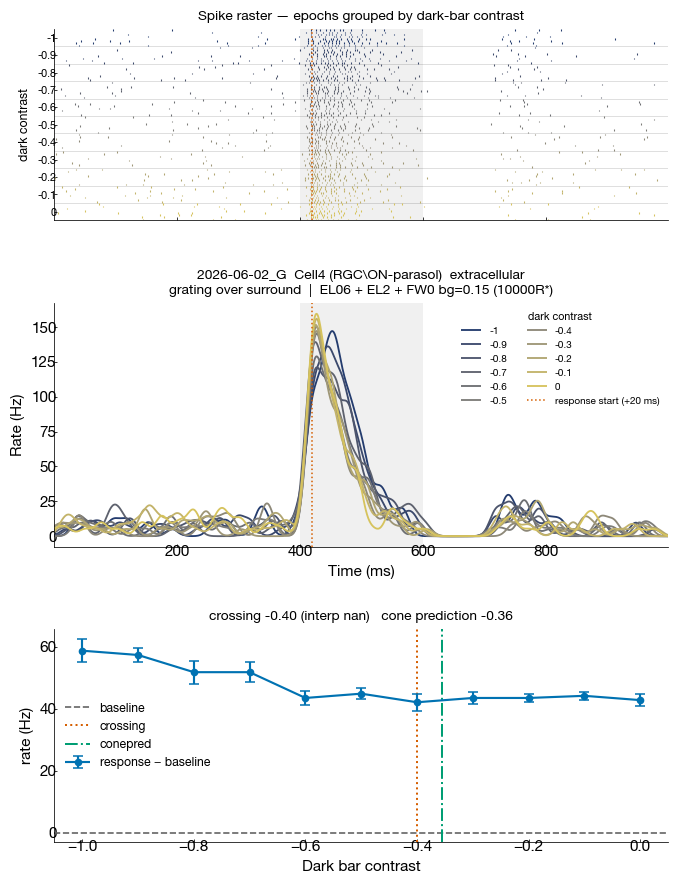

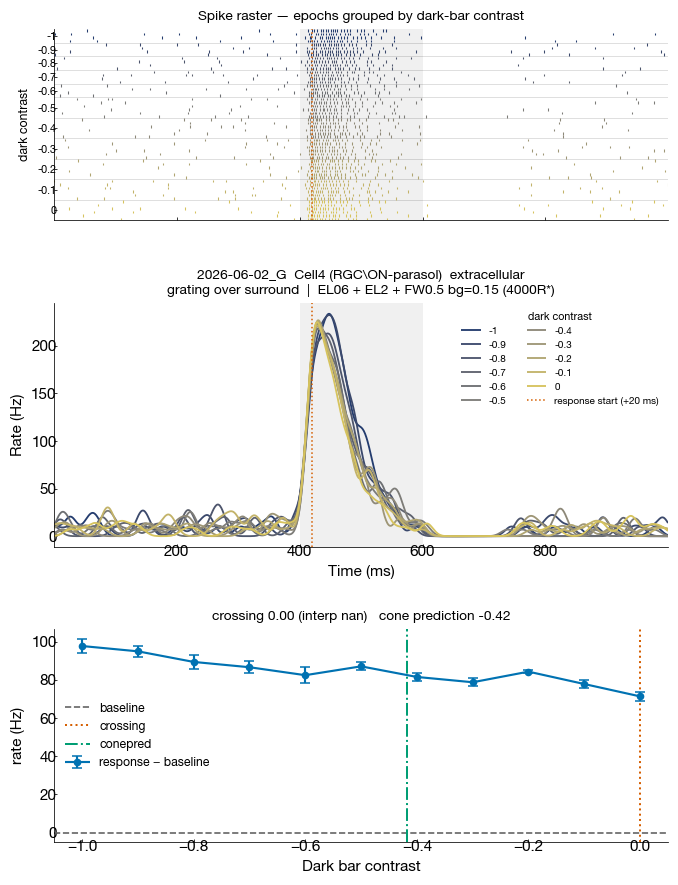

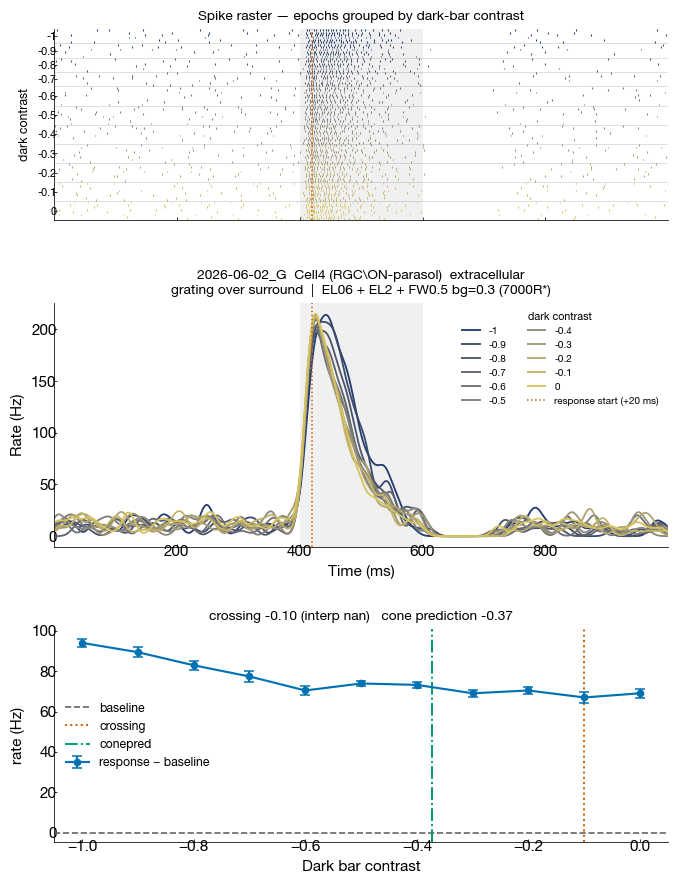

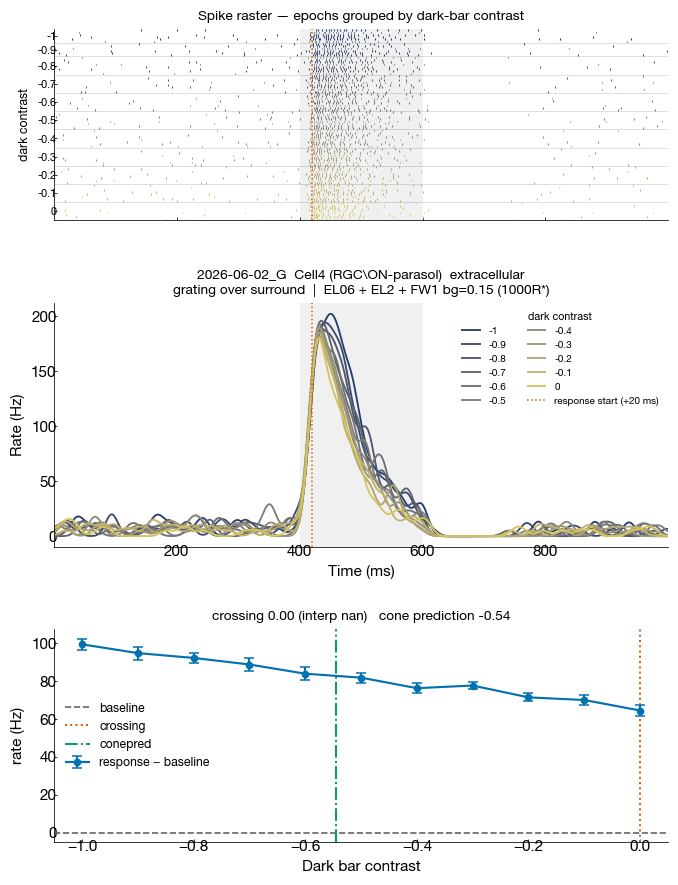

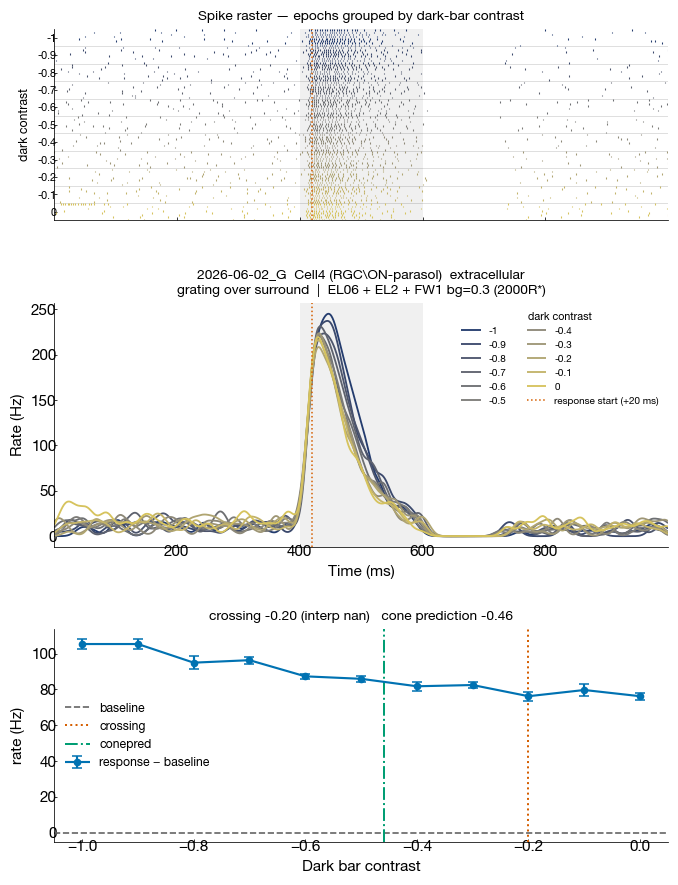

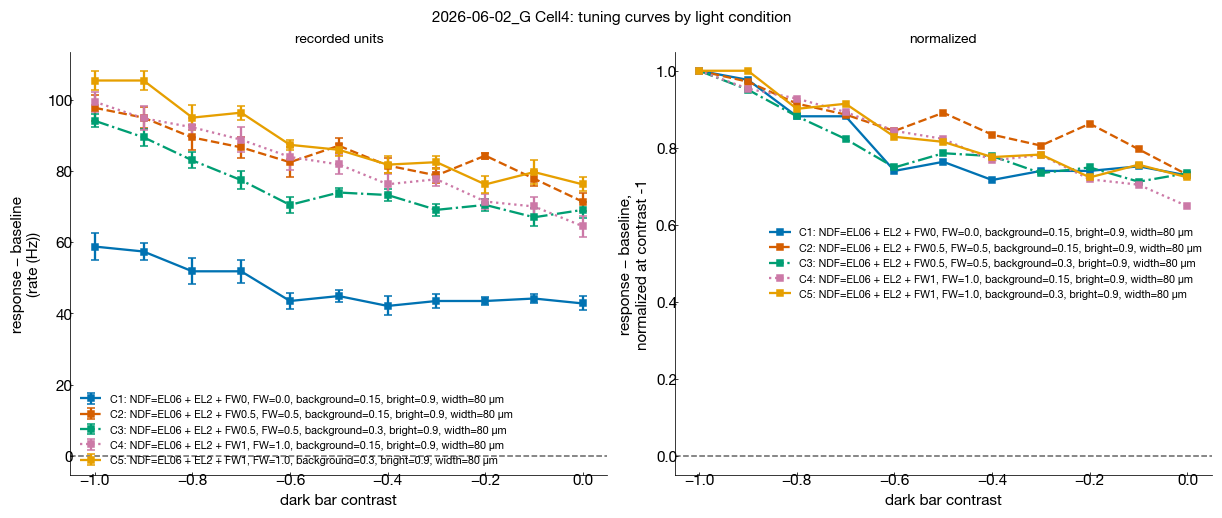

In [49]:
# Standalone after the import cell; Section 2 is optional.
DATE_INDEX = 26
CELL_LABEL = 'Cell4'
ONLINE_ANALYSIS = 'extracellular'  # 'extracellular', 'exc', or 'inh'
COLLAPSE_BAR_WIDTHS = True
SUBTRACT_BASELINE = True
SPIKE_OFFSET_MS = 20.0
WC_OFFSET_MS = 30.0
DETECTOR_KWARGS = {
    'min_peak_amplitude': 10.0,
    'max_trial_length_s': 2.0,
    'cluster_across_trials': True,
    'global_polarity': True,
}

section3 = sag.analyze_cell_conditions(
    date_index=DATE_INDEX,
    cell_label=CELL_LABEL,
    online_analysis=ONLINE_ANALYSIS,
    site=SITE,
    collapse_bar_widths=COLLAPSE_BAR_WIDTHS,
    subtract_baseline=SUBTRACT_BASELINE,
    max_series_resistance=MAX_SERIES_RESISTANCE,
    spike_offset=SPIKE_OFFSET_MS,
    wc_offset=WC_OFFSET_MS,
    detector_kwargs=DETECTOR_KWARGS,
    keep_raw=True,
    plot=True,
    show=True)

# Short aliases retained for Sections 3a and 5.
EXP_NAME = section3.exp_name
condition_rows = section3.condition_rows
light_conditions = section3.light_conditions
records = section3.records
condition_figures = section3.condition_figures
light_tuning_figure = section3.light_tuning_figure


### 3a. Save these conditions for population analysis

Save every analyzed condition to the site-specific HDF5 store. The key includes
date, cell, mode, site, fixed NDFs, numeric FilterWheel, background, bright-bar
contrast, and the analyzed bar-width set. Therefore multiple light/background/bar
conditions from the same cell remain separate entries; rerunning an identical
condition replaces only that entry.

In [43]:
if not records:
    raise ValueError('Run Section 3 before saving')
condition_output_path = sag.save_records(records, path=STORE_PATH)
saved_light_audit = sag.audit_saved_light_settings(
    path=STORE_PATH, repair=True, verify_raw_h5=True)
print(f'Saved {len(records)} separate condition(s) to {condition_output_path}')

  added 2026-04-23_E__Cell5__extracellular__surround__FW0__bg0p5__EL3-FW0__bright0p9__bar100
  added 2026-04-23_E__Cell5__extracellular__surround__FW1__bg0p5__EL3-FW1__bright0p9__bar100
2 record(s) saved -> /Volumes/ChrisNewSSD/retinanalysis_output/spot_annular_grating/surround_grating/records.h5 (23 rows total)
FilterWheel/NDF audit: all 23 saved condition(s) agree
Saved 2 separate condition(s) to /Volumes/ChrisNewSSD/retinanalysis_output/spot_annular_grating/surround_grating/records.h5


### 3b. Check spike detection on a random subset of epochs

For extracellular recordings, plot raw amplifier traces with detected spikes marked.
This optional check is disabled by default; set `RUN_SPIKE_DETECTION_QC = True`
to run it. `SPIKE_QC_FRACTION` controls the sampled fraction (default 30%), and
`SPIKE_QC_RANDOM_SEED` makes the selection reproducible; set it to `None` to draw a
new random subset each run. Sampling occurs separately within every analyzed light
condition. Use the `QC view` pull-down to inspect one sampled epoch at a time without
stacking every trace vertically. The protocol-independent
`ra.spike_detection_qc_browser` utility handles sampling, deduplication, plotting,
and the compact pull-down display for this and other protocol notebooks.

In [5]:
RUN_SPIKE_DETECTION_QC = False
SPIKE_QC_FRACTION = 0.30
SPIKE_QC_RANDOM_SEED = 0  # Set to None for a new random subset each run.
SPIKE_QC_EPOCHS_PER_VIEW = 1  # Keep each pull-down view compact.

if RUN_SPIKE_DETECTION_QC and not records:
    raise ValueError('Run Section 3 before checking spike detection')

spike_qc_datasets = []
for condition_index, record in enumerate(
        records if RUN_SPIKE_DETECTION_QC else [], start=1):
    if record.online_analysis != 'extracellular':
        continue
    if record.raw is None or not record.raw.get('traces'):
        print(f'Condition {condition_index}: no raw traces; rerun Section 3 with keep_raw=True.')
        continue

    spike_qc_datasets.append({
        'label': f'Condition {condition_index}',
        'title': (f'Condition {condition_index}: {record.exp_name} | '
                  f'{record.cell_label} | {record.config.get("ndf_combination", "")}'),
        'traces': record.raw['traces'],
        'spike_times': record.raw['spike_times_ms'],
        'sample_rate': record.raw['sample_rate'],
        'spike_time_unit': 'ms',
        'stimulus_window_ms': (
            record.pre_time_ms, record.pre_time_ms + record.stim_time_ms),
        'source_group': record.exp_name,
        'block_ids': record.raw.get('block_id'),
        'epoch_indices': record.raw.get('epoch_index'),
    })

if not RUN_SPIKE_DETECTION_QC:
    print('Spike-detection QC skipped. Set RUN_SPIKE_DETECTION_QC = False to enable it.')
    spike_detection_qc = None
elif not spike_qc_datasets:
    print('No extracellular records are available for spike-detection QC.')
    spike_detection_qc = None
else:
    spike_detection_qc = ra.spike_detection_qc_browser(
        spike_qc_datasets,
        fraction=SPIKE_QC_FRACTION,
        random_state=SPIKE_QC_RANDOM_SEED,
        epochs_per_view=SPIKE_QC_EPOCHS_PER_VIEW)

Spike-detection QC skipped. Set RUN_SPIKE_DETECTION_QC = False to enable it.


### 3c. Check saved conditions

Load only the scalar index. Every NDF/background/bright/bar-width condition is one
row; trace arrays remain on disk until a plot requests them.

In [50]:
saved_light_audit = sag.audit_saved_light_settings(
    path=STORE_PATH, repair=True, verify_raw_h5=True)
saved_cells = sag.load_summary(path=STORE_PATH)
saved_columns = [
    'exp_name', 'cell_label', 'cell_type', 'online_analysis', 'ndf_combination',
    'max_light_level', 'background_intensity', 'bright_bar_contrast',
    'bar_widths', 'rstar', 'series_resistance', 'n_epochs_high_rs',
    'n_epochs', 'block_ids',
]
saved_columns = [column for column in saved_columns if column in saved_cells]
print(f'{len(saved_cells)} saved {SITE}-grating condition(s)')
sc.scroll_table(
    saved_cells[saved_columns], height=320,
    num_cols=('max_light_level', 'background_intensity', 'bright_bar_contrast',
              'rstar', 'series_resistance', 'n_epochs_high_rs', 'n_epochs'))

FilterWheel/NDF audit: all 23 saved condition(s) agree
23 saved surround-grating condition(s)


exp_name,cell_label,cell_type,online_analysis,ndf_combination,max_light_level,background_intensity,bright_bar_contrast,bar_widths,rstar,series_resistance,n_epochs_high_rs,n_epochs,block_ids
2025-10-22_E,Cell3,RGC\OFF-parasol,extracellular,EL3 + FW0,30000.0,0.3,1.0,100,9000.0,0.0,0,99,"18860,18861,18862"
2025-11-06_E,Cell4,RGC\OFF-parasol,extracellular,EL3 + FW0,30000.0,0.3,1.0,100,9000.0,0.0,0,99,"18934,18935,18936"
2026-04-14_E,Cell1,RGC\OFF-parasol,extracellular,EL3 + FW0,30000.0,0.5,0.9,75,15000.0,0.0,0,55,33997
2025-10-15_E,Cell6,RGC\ON-parasol,extracellular,FW0,30000.0,0.3,1.0,100,9000.0,0.0,0,209,"18847,18848,18849,18850"
2025-10-15_E,Cell7,RGC\ON-parasol,extracellular,FW0,30000.0,0.3,1.0,100,9000.0,0.0,0,66,"18816,18817"
2025-10-22_E,Cell1,RGC\ON-parasol,extracellular,EL3 + FW0,30000.0,0.3,1.0,100,9000.0,0.0,0,66,"18856,18857"
2025-10-22_E,Cell4,RGC\ON-parasol,extracellular,EL3 + FW0,30000.0,0.3,1.0,100,9000.0,0.0,0,33,18890
2025-11-06_E,Cell1,RGC\ON-parasol,extracellular,EL3 + FW0,30000.0,0.3,1.0,100,9000.0,0.0,0,66,"18917,18918"
2025-11-06_E,Cell2,RGC\ON-parasol,extracellular,EL3 + FW0,30000.0,0.3,1.0,100,9000.0,0.0,0,99,"18911,18912,18913"
2025-11-06_E,Cell3,RGC\ON-parasol,extracellular,EL3 + FW0,30000.0,0.3,1.0,100,9000.0,0.0,0,66,"18940,18941"


'\n<style>\n.ra-tbl { overflow: auto; }\n.ra-tbl table { border-collapse: collapse; font-size: 12.5px;\n                font-variant-numeric: tabular-nums; }\n.ra-tbl th { position: sticky; top: 0; z-index: 1; text-align: left;\n             font-weight: 600; padding: 4px 12px 4px 0;\n             border-bottom: 1px solid rgba(128,128,128,0.6);\n             background: var(--jp-layout-color0, #fff); }\n.ra-tbl td { padding: 2px 12px 2px 0; vertical-align: top;\n             white-space: nowrap; }\n.ra-tbl tr.grp > td { border-top: 1px solid rgba(128,128,128,0.28); }\n.ra-tbl td.num { text-align: right; }\n.ra-tbl td.lead { font-weight: 600; }\n.ra-tbl summary { cursor: pointer; margin: 2px 0; }\n</style>\n<div class="ra-tbl" style="max-height:320px"><table><thead><tr><th>exp_name</th><th>cell_label</th><th>cell_type</th><th>online_analysis</th><th>ndf_combination</th><th>max_light_level</th><th>background_intensity</th><th>bright_bar_contrast</th><th>bar_widths</th><th>rstar</th><th>s

## 4. Population analysis

Restricted to one cell type at a time — `POPULATION_CELL_TYPE`, ON-parasol for
now — and to one recording mode. Saved light settings are checked against the
direct FilterWheel and fixed-NDF readings first. Missing FilterWheel values remain
missing and are printed rather than silently assumed to be FW0.

**Bright-bar contrast is no longer filtered.** Both 0.9 and 1.0 blocks are kept,
and the x axis is the dark bar divided by that record's own bright bar,
$C_-/C_+$. That is what makes the two comparable: the bars are equal in magnitude
only where the ratio is $-1$, so a $C_-=-0.9$ dark bar is the balanced stimulus
against $C_+=0.9$ but a deeper-than-balanced one against $C_+=1.0$. Normalizing
at $C_-/C_+=-1$ therefore divides every cell by its response to the balanced
grating, which is a stimulus both groups actually ran.

The ratio puts the two bright bars on different grids — 1.0 steps by 0.1, 0.9 by
0.111, and they share only $-1$ and $0$ — so the population figures pass
`interpolate=True` and resample each cell onto the union grid before averaging.
Without it the contributing cell count alternates 11, 4, 11, 4 between
neighbouring x and the mean picks up a sawtooth from the sampling. Interpolation
is linear and never extrapolates, which is why the leftmost point
($C_-/C_+=-1.11$) still rests on the 0.9 cells alone — only they were driven that
deep in ratio terms. The individual-curve figure is left uninterpolated: it shows
what was measured.

The first figure shows every cell's baseline-subtracted curve in Hz before
normalization. The second normalizes each cell at $C_-/C_+=-1$; the third
normalizes to each cell's maximum. Lines show the population mean and shading the
SEM across cells. The cone-model cancellation prediction depends on the bright bar
and dividing by $C_+$ does not cancel that — at 12000 R*/s it is $-0.393$ for
$C_+=0.9$ and $-0.368$ for $C_+=1.0$ — so a panel pooling both draws the span
between them rather than a single star.

In [ ]:
POPULATION_CELL_TYPE = 'ON-parasol'
POPULATION_MODE = 'extracellular'
POPULATION_LIGHT_BANDS = ((8000.0, 16000.0, 12000.0),)
POPULATION_NORMALIZATION_CONTRAST = -1.0
POPULATION_CONE_W = 2000.0

population_light_audit = sag.audit_saved_light_settings(
    path=STORE_PATH, repair=True, verify_raw_h5=True)
summary = sag.add_condition(sag.load_summary(path=STORE_PATH))
if summary.empty:
    raise ValueError(f'No saved {SITE}-grating records in {STORE_PATH}')

# Bright-bar contrast is deliberately not filtered; the ratio axis handles it.
population_summary = summary[
    summary.online_analysis.eq(POPULATION_MODE)
    & summary.cell_type_short.eq(POPULATION_CELL_TYPE)
].copy()
population_summary = sag.select_population_light_bands(
    population_summary, bands=POPULATION_LIGHT_BANDS)
if population_summary.empty:
    raise ValueError('No records matched the requested population light bands')

population_summary['cell_id'] = (
    population_summary.exp_name.astype(str) + '/'
    + population_summary.cell_label.astype(str))
population_bright_contrasts = tuple(
    sorted(population_summary.bright_bar_contrast.dropna().unique()))
population_table = (population_summary
    .groupby(['rstar_level', 'bright_bar_contrast'], dropna=False)
    .agg(records=('key', 'size'), cells=('cell_id', 'nunique'),
         epochs=('n_epochs', 'sum'), min_rstar=('rstar', 'min'),
         max_rstar=('rstar', 'max'))
    .reset_index())
sc.scroll_table(
    population_table, height=180,
    num_cols=('rstar_level', 'bright_bar_contrast', 'records', 'cells', 'epochs',
              'min_rstar', 'max_rstar'))

population_conditions = tuple(
    population_summary.condition.dropna().drop_duplicates())
population_records = sag.load_records(
    population_summary.key.tolist(), path=STORE_PATH)
for bright in population_bright_contrasts:
    predicted = sag.cone_predict_dark_contrast(12000.0, bright, POPULATION_CONE_W)
    print(f'Cone prediction at 12000 R*/s, C+={bright:g}: '
          f'C-={predicted:.4f}  (ratio {predicted / bright:.4f})')

# Individual curves stay on the measured grid -- no interpolation.
individual_tuning_figure = sag.plot_population_individual_tuning(
    population_summary, records=population_records, negative_only=True,
    contrast_axis='ratio', allowed_bright_contrast=None,
    figsize=(12.0, 4.8))

population_controls = dict(
    records=population_records, negative_only=True, min_cells=2,
    contrast_axis='ratio', interpolate=True, allowed_bright_contrast=None,
    require_positive_reference=True,
    conditions=population_conditions, modes=(POPULATION_MODE,),
    cone_prediction_bright_contrast=population_bright_contrasts,
    cone_prediction_i0=POPULATION_CONE_W,
    figsize=(7.2, 5.0))

population_figure = sag.plot_population_tuning(
    population_summary, normalize=True,
    normalization_contrast=POPULATION_NORMALIZATION_CONTRAST,
    title=f'{POPULATION_CELL_TYPE} population normalized at $C_-/C_+ = -1$',
    **population_controls)

population_max_response_figure = sag.plot_population_tuning(
    population_summary, normalize=True,
    normalization_mode='max_response', report_excluded=False,
    title=f'{POPULATION_CELL_TYPE} population normalized to each cell maximum',
    **population_controls)

## 5. Split-field model: net response vs. dark/bright contrast ratio

For an equal-area split field, define the signed ratio $\rho=C_-/C_+$, with
$C_+>0$ and $\beta=I_b/W$. The two half-field responses are combined linearly
*after* each has undergone its intensity-dependent Weber-like gain discount:

$$
R_{\mathrm{net}}(\rho)=\frac{I_bC_+}{2}\left[
\frac{1}{1+\beta(1+C_+)}+
\frac{\rho}{1+\beta(1+\rho C_+)}\right].
$$

The plotted physical domain is $-1/C_+ \leq \rho \leq 0$; its left endpoint
sets the dark-half intensity to zero. Circles mark the analytic cancellation ratio
$\rho_{\mathrm{cancel}}=-(1+\beta)/(1+\beta+2\beta C_+)$, and the dotted
line at $\rho=-1$ marks equal bright and dark contrast magnitudes. Because these
curves represent an OFF cell, the plotted response has the model sign reversed; each
background is divided by its own maximum response so the five curves peak at 1.


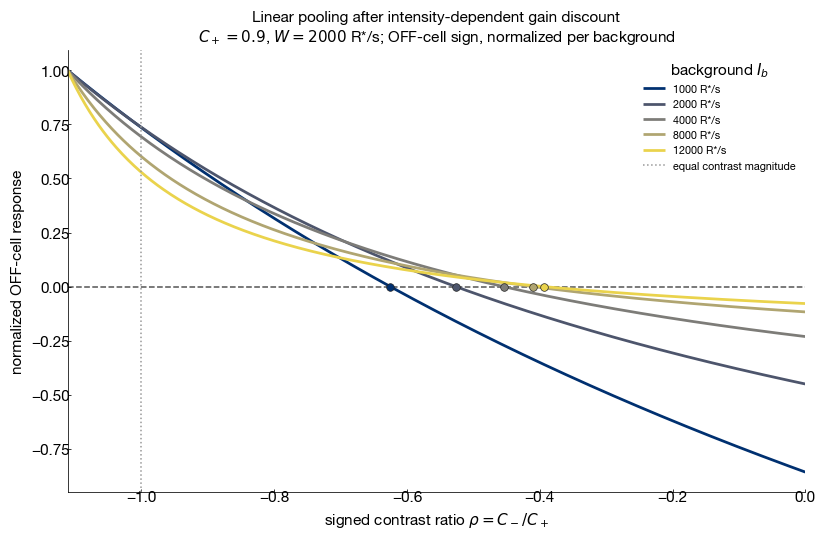

In [9]:
RATIO_RESPONSE_BACKGROUNDS = (1000, 2000, 4000, 8000, 12000)
RATIO_RESPONSE_BRIGHT_CONTRAST = 0.9
RATIO_RESPONSE_W = 2000.0
RATIO_RESPONSE_OFF_CELL = True
RATIO_RESPONSE_NORMALIZE_EACH = True

ratio_response_figure = sag.plot_split_field_ratio_response(
    backgrounds=RATIO_RESPONSE_BACKGROUNDS,
    bright_contrast=RATIO_RESPONSE_BRIGHT_CONTRAST,
    i0=RATIO_RESPONSE_W,
    off_cell=RATIO_RESPONSE_OFF_CELL,
    normalize_each=RATIO_RESPONSE_NORMALIZE_EACH)

## 6. Example surround-grating stimulus

Render the selected block using the recorded aperture, annulus, bar width,
background, spot intensity, and bright/dark contrasts. The geometry should visibly
place the grating over the **surround**; the center spot remains an independent protocol
parameter for surround recordings.


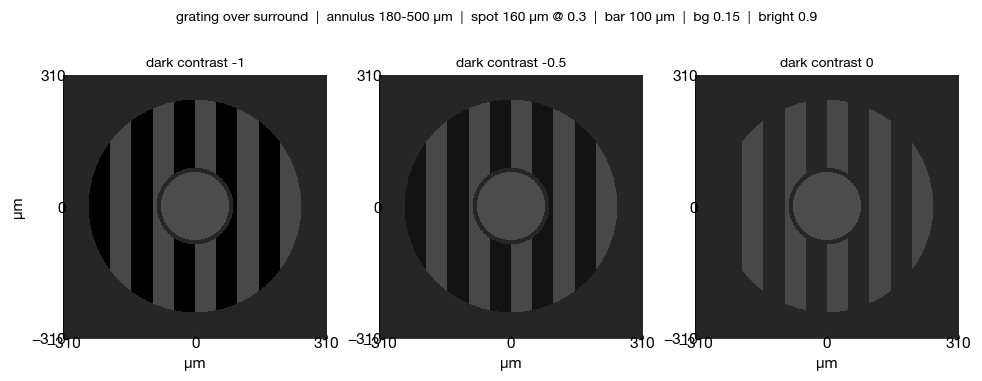

In [10]:
EXAMPLE_CONDITION_INDEX = 1
if not 1 <= EXAMPLE_CONDITION_INDEX <= len(records):
    raise ValueError(f'EXAMPLE_CONDITION_INDEX must be 1-{len(records)}')
example_record = records[EXAMPLE_CONDITION_INDEX - 1]
example_block = int(example_record.block_ids[0])
stim = ra.StimBlock(example_record.exp_name, example_block, verbose=False)
example_parameters = stim.df_epochs['epoch_parameters'].iloc[0]
dark_values = np.sort(stim.df_epochs['currentDarkContrast'].dropna().unique())
example_dark = dark_values[[0, len(dark_values) // 2, -1]]
stimulus_figure = sag.plot_stimulus_schematic(
    example_parameters, dark_contrasts=example_dark)